### Current status 
Using a Zprime to ttbar run 2 sample as an example 

In [1]:
import atlasopenmagic as atom

In [2]:
key=301333

In [3]:
atom.get_metadata(key)

Fetching and caching all metadata for release: 2024r-pp...
Fetched 374 datasets so far...
Successfully cached 374 datasets.


{'dataset_number': '301333',
 'physics_short': 'Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt',
 'e_tag': 'e3723',
 'cross_section_pb': 0.0050843,
 'genFiltEff': 1.0,
 'kFactor': 1.0,
 'nEvents': 30000,
 'sumOfWeights': 30000.0,
 'sumOfWeightsSquared': 30000.0,
 'process': 'pp>Zprime>ttbar',
 'generator': 'Pythia8(v8.186)+EvtGen(v1.2.0)',
 'keywords': ['BSM', 'Zprime', 'resonance', 'ttbar'],
 'description': 'SSM Z prime (+str(m_zprime)+") to ttbar"',
 'job_path': 'https://gitlab.cern.ch/atlas-physics/pmg/infrastructure/mc15joboptions/-/tree/master/share/DSID301xxx/MC15.301333.Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt.py',
 'CoMEnergy': None,
 'GenEvents': None,
 'GenTune': None,
 'PDF': None,
 'Release': None,
 'Filters': None,
 'cross_section_uncertainty': None,
 'hepmc_version': None,
 'release': {'name': '2024r-pp'}}

In [23]:
atom.get_urls(key)

['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.38191516._000001.pool.root.1']

From the URls one would stream or download to the local
- Select the protocol
    - "https", "eos", "xrootd"
    - Install fsspec-xrootd to access xrootd storage system
- Multiple skim type including 'noskim'

## Data delivery and transformation with with SeriveX 
Built a wrapper that calls ServiceX functions to build transformation requests, find datasets, send queries to endpoint... 

First setup for ServiceX in [instructions](https://servicex-frontend.readthedocs.io/en/stable/connect_servicex.html) 

In [5]:
atom.fetch_data

<function atlasopenmagic.servicex_wrap.fetch_data(dataset: str | int, tree: str, branch_filter: str | list[str], selection: str | None = None, nfiles: int = 500, arrays: bool = True, **kwargs)>

### Filtering columns with `fetch_data`

In [6]:
#Tree to inspect in Physlite
tree="CollectionTree"
#Column of interest
branch="AnalysisElectronsAuxDyn.pt"

In [7]:
result=atom.fetch_data(key, tree = tree, branch_filter = branch)

Output()

In [8]:
result

{'301333': <Array [{...}, {...}, {...}, ..., {...}, {...}] type='30000 * {"nAnalysisEl...'>}

In [9]:
type(result["301333"])

awkward.highlevel.Array

In [10]:
result["301333"].fields

['nAnalysisElectronsAuxDyn.pt', 'AnalysisElectronsAuxDyn.pt']

#### Point to files instead in local cache

In [12]:
result_files=atom.fetch_data(key, tree = tree, branch_filter = branch, arrays = False)
print(result_files)

Output()

{'301333': ['/private/var/folders/rl/c_v3j6t97j51xfs8rjlh0sfx2djbcf/T/servicex_acordeir/e030f4ff-70cb-4f1d-902a-e87482cc4c17/root___192.170.240.195_1094__root___eospublic.cern.ch_1094__eos_opendata_atlas_rucio_mc20_13TeV_DAOD_PHYSLITE.38191516._000001.pool.root.1']}


#### Filter can accept multiple columns

In [13]:
branches = ["AnalysisElectronsAuxDyn.pt", "AnalysisElectronsAuxDyn.eta", "AnalysisElectronsAuxDyn.phi"]

In [14]:
result_many = atom.fetch_data(key, tree = tree, branch_filter = branches)

Output()

In [15]:
result_many["301333"].fields

['nAnalysisElectronsAuxDyn.pt',
 'AnalysisElectronsAuxDyn.pt',
 'nAnalysisElectronsAuxDyn.eta',
 'AnalysisElectronsAuxDyn.eta',
 'nAnalysisElectronsAuxDyn.phi',
 'AnalysisElectronsAuxDyn.phi']

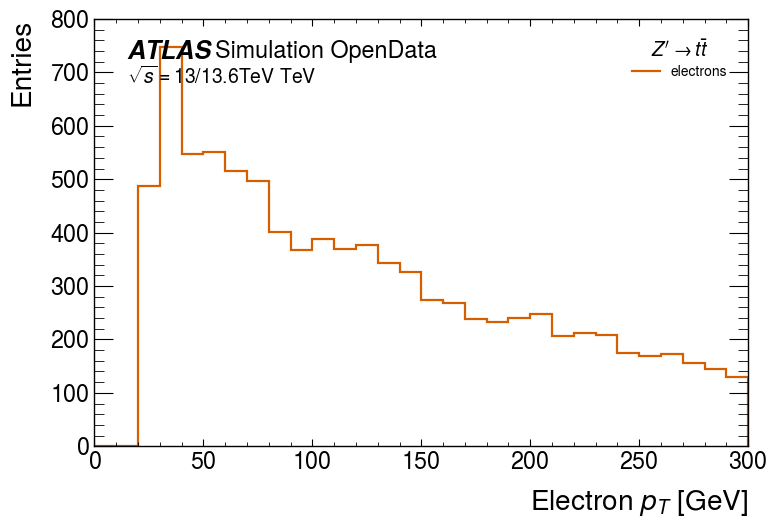

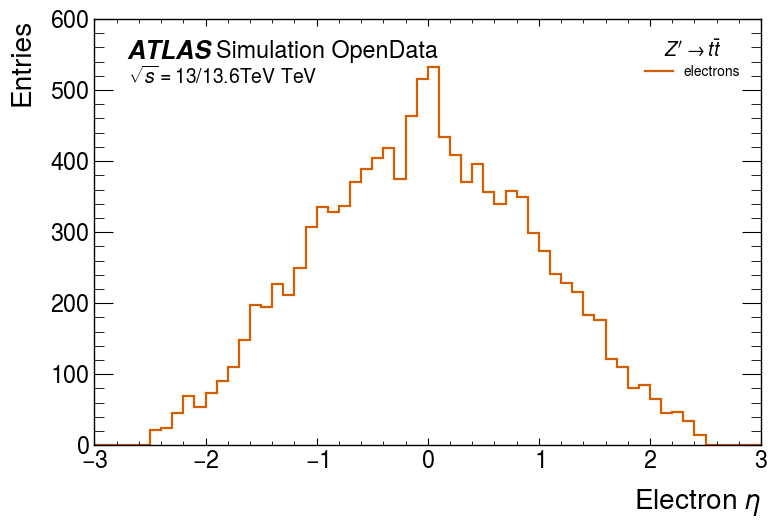

In [16]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep

normalize = False
mplhep.style.use("ATLAS")

arr = result_many["301333"]  

PT_KEY  = "AnalysisElectronsAuxDyn.pt"
ETA_KEY = "AnalysisElectronsAuxDyn.eta"

pt_bins  = np.linspace(0, 300, 31)     # 10 GeV bins
eta_bins = np.linspace(-3.0, 3.0, 61)  # 0.1 bins

mask = arr[PT_KEY] > 25_000

label = r"$Z^\prime \to t\bar{t}$"


# ==================== pT ====================
xlabel = r"Electron $p_T$ [GeV]"
hists = {}
edges = None

x = ak.to_numpy(ak.ravel(arr[PT_KEY][mask])) / 1000.0  # MeV -> GeV
y, edges = np.histogram(x, bins=pt_bins)
if normalize and y.sum() > 0:
    y = y / y.sum()
hists["electrons"] = y.astype(float)

fig, ax = plt.subplots(figsize=(8, 5.5))
for name, y in hists.items():
    mplhep.histplot(y, bins=edges, ax=ax, histtype="step", label=name, linewidth=1.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("Arbitrary units" if normalize else "Entries")
ax.set_xlim(pt_bins[0], pt_bins[-1])
ax.legend(title=label, ncol=3, fontsize=10)
mplhep.atlas.label("OpenData", ax=ax, data=False, com="13/ 13.6 TeV")

plt.tight_layout()
plt.show()

# ==================== eta ====================
xlabel = r"Electron $\eta$"
hists = {}
edges = None

x = ak.to_numpy(ak.ravel(arr[ETA_KEY][mask]))  # unitless
y, edges = np.histogram(x, bins=eta_bins)
if normalize and y.sum() > 0:
    y = y / y.sum()
hists["electrons"] = y.astype(float)

fig, ax = plt.subplots(figsize=(8, 5.5))
for name, y in hists.items():
    mplhep.histplot(y, bins=edges, ax=ax, histtype="step", label=name, linewidth=1.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("Arbitrary units" if normalize else "Entries")
ax.set_xlim(eta_bins[0], eta_bins[-1])
ax.legend(title=label, ncol=3, fontsize=10)
mplhep.atlas.label("OpenData", ax=ax, data=False, com="13/ 13.6 TeV")
plt.tight_layout()

## Filtering with custom events selection

ServiceX `UprootRawQuery` being used in `fetch_data` accepts expression cuts with awkward functions such as `ak.sum`, `ak.any` that broadcast through the arrays nested structures

In [17]:
atom.fetch_data

<function atlasopenmagic.servicex_wrap.fetch_data(dataset: str | int, tree: str, branch_filter: str | list[str], selection: str | None = None, nfiles: int = 500, arrays: bool = True, **kwargs)>

In [18]:
selection = (
    "(sum(AnalysisJetsAuxDyn.pt > 25000, axis=1) > 3)"                          # at least 4 jets with Pt > 25 GeV
    " & (any(AnalysisElectronsAuxDyn.pt > 25000, axis=1))"                      # at least 1 electron with Pt > 25 GeV
)


In [19]:
selected_events =atom.fetch_data(key, tree = tree, branch_filter = branches, selection = selection)

Output()

In [20]:
eff=len(selected_events[str(key)])/len(result[str(key)])*100
print(f"The selection cuts correspond to a {eff:2.1f} % efficiency on sample {key}")

The selection cuts correspond to a 26.7 % efficiency on sample 301333


## Getting the file structure first
In order to work with ServiceX one must be aware of available columns inside the sample.  
`servicex_analysis_utils.get_structure()` can be wrapped up inside `atom` for the same purpose.

In [21]:
atom.get_structure

<function atlasopenmagic.servicex_wrap.get_structure(dataset: str | int, **kwargs)>

In [22]:
physlite_structure = atom.get_structure(301333, filter_branch="AnalysisElectrons")
print(physlite_structure)

Output()


---------------------------
📁 Sample: Dataset
---------------------------

File Metadata ℹ️ :

── amiTag: e3723_s3681_r13167_r13146_p6026
── beamEnergy: 6500000.0
── beamType: collisions
── conditionsTag: OFLCOND-MC16-SDR-RUN2-09
── geometryVersion: ATLAS-R2-2016-01-00-01
── isDataOverlay: 0
── mcProcID: 301333.0
── simFlavour: FullG4
── mcCampaign: mc20a

---------------------------

File structure with branch filter 🌿 'AnalysisElectrons':


🌳 Tree: ##Params;3
   ├── Branches:

🌳 Tree: ##Params;2
   ├── Branches:

🌳 Tree: ##Shapes;3
   ├── Branches:

🌳 Tree: ##Shapes;2
   ├── Branches:

🌳 Tree: ##Links;3
   ├── Branches:

🌳 Tree: ##Links;2
   ├── Branches:

🌳 Tree: MetaData
   ├── Branches:

🌳 Tree: MetaDataHdr
   ├── Branches:

🌳 Tree: MetaDataHdrForm
   ├── Branches:

🌳 Tree: CollectionTree
   ├── Branches:
   │   ├── AnalysisElectronsAux. ; dtype: AsStridedObjects(Model_xAOD_3a3a_AuxContainerBase_v1)
   │   ├── AnalysisElectrons ; dtype: AsObjects(Unknown_DataVector_3c_xAOD_3a3a_E

#### Very usefull to send similar queries on different sample types. For example, on a nutple produced via `TopCPToolkit` one needs to change tree and branch names

## Other input types 

This `atom` wrapper allows data access through all datasetfinder protocols ServiceX can handle. 

This includes:
- rucio - `scope:somesample or just somesample`
- xrootd - `root://`
- HTTPS - URLs, Signed URLs
- filelist - multiple links at once 
- eos path - `/eos/opendata/atlas/rucio/somefile.root`
- cernopendata portal ID - `80018` 


All of these work as input of an internal helper `atom.servicex_wrap._sample_finder`